# EDA: Synthetic Banking Transactions

This notebook documents checkpoint 3 progress:
- dataset loading and validation,
- descriptive statistics,
- visual analysis,
- concise findings.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path(r'C:/Users/vadim/Desktop/elena')
DATA = ROOT / 'data' / 'synthetic'
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True, parents=True)

users = pd.read_csv(DATA / 'users.csv')
transactions = pd.read_csv(DATA / 'transactions.csv')
offers = pd.read_csv(DATA / 'offers.csv')
interactions = pd.read_csv(DATA / 'interactions.csv')

transactions['timestamp'] = pd.to_datetime(transactions['timestamp'])
interactions['timestamp'] = pd.to_datetime(interactions['timestamp'])

print('users:', len(users))
print('transactions:', len(transactions))
print('offers:', len(offers))
print('interactions:', len(interactions))

users: 800
transactions: 112626
offers: 15
interactions: 6442


## 1. Data Quality Checks

In [2]:
quality = {
    'users_missing': int(users.isna().sum().sum()),
    'transactions_missing': int(transactions.isna().sum().sum()),
    'offers_missing': int(offers.isna().sum().sum()),
    'interactions_missing': int(interactions.isna().sum().sum()),
    'duplicate_transaction_id': int(transactions['transaction_id'].duplicated().sum()),
    'duplicate_interaction_id': int(interactions['interaction_id'].duplicated().sum()),
}
quality

{'users_missing': 0,
 'transactions_missing': 0,
 'offers_missing': 0,
 'interactions_missing': 0,
 'duplicate_transaction_id': 0,
 'duplicate_interaction_id': 0}

## 2. Category-Level Behavior

In [3]:
cat_stats = (
    transactions.groupby('category')
    .agg(
        transactions=('transaction_id', 'count'),
        avg_amount=('amount', 'mean'),
        median_amount=('amount', 'median'),
        total_amount=('amount', 'sum'),
    )
    .sort_values('transactions', ascending=False)
)
cat_stats.head(10)

,transactions,avg_amount,median_amount,total_amount
category,,,,
transport,10672,705.883096,648.340,7.533184e+06
restaurants,10584,1588.232149,1392.635,1.680985e+07
groceries,9849,1971.465393,1783.320,1.941696e+07
entertainment,9789,2628.082313,2214.940,2.572630e+07
education,9222,9342.431993,6717.805,8.615591e+07
investments,7771,24056.786643,13246.840,1.869453e+08
electronics,7646,22453.826692,15011.880,1.716820e+08
insurance,7487,11938.318833,9638.800,8.938219e+07
money_transfer,7235,4305.303865,3611.450,3.114887e+07


C:\Users\vadim\AppData\Local\Temp\ipykernel_8828\3479004703.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


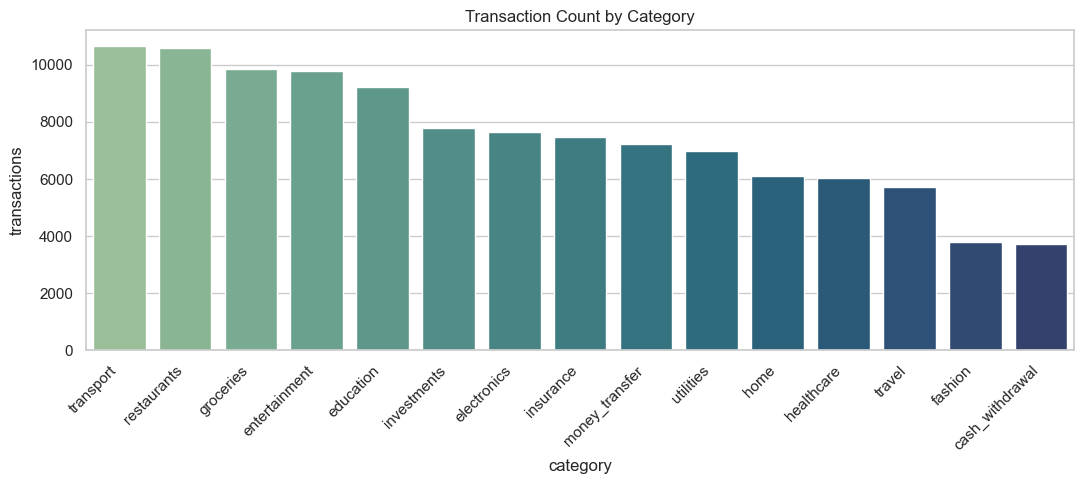

In [4]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=cat_stats.reset_index(),
    x='category',
    y='transactions',
    palette='crest'
)
plt.xticks(rotation=45, ha='right')
plt.title('Transaction Count by Category')
plt.tight_layout()
plt.show()

## 3. Amount Distribution

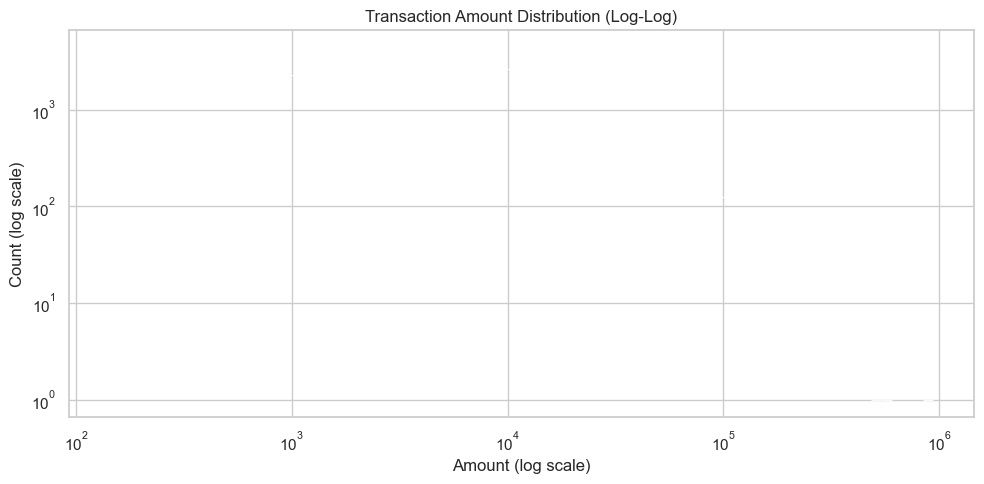

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(transactions['amount'], bins=80, log_scale=(True, True), color='#1f77b4')
plt.xlabel('Amount (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Transaction Amount Distribution (Log-Log)')
plt.tight_layout()
plt.show()

## 4. User-Level Aggregates

In [6]:
user_stats = (
    transactions.groupby('user_id')
    .agg(
        n_transactions=('transaction_id', 'count'),
        total_amount=('amount', 'sum'),
        avg_amount=('amount', 'mean'),
    )
    .reset_index()
)
user_stats.describe().T

,count,mean,std,min,25%,50%,75%,max
n_transactions,800.0,1.407825e+02,11.771721,101.000000,133.000000,1.410000e+02,1.480000e+02,1.930000e+02
total_amount,800.0,1.158123e+06,427276.744726,236379.080000,841232.752500,1.102653e+06,1.388166e+06,2.833421e+06
avg_amount,800.0,8.226187e+03,2964.635671,2148.900727,6048.443355,7.863394e+03,9.845488e+03,2.162917e+04


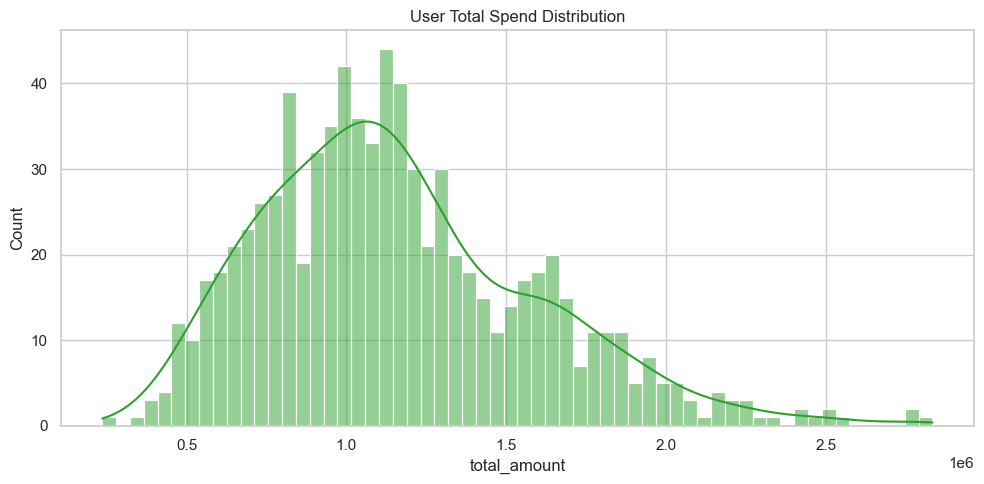

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(user_stats['total_amount'], bins=60, kde=True, color='#2ca02c')
plt.title('User Total Spend Distribution')
plt.tight_layout()
plt.show()

## 5. Temporal Pattern

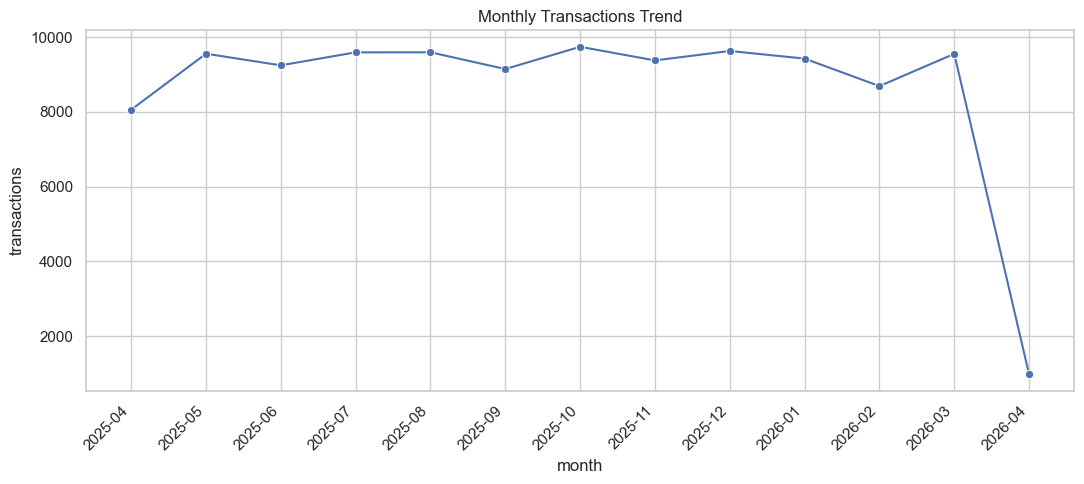

In [8]:
monthly = (
    transactions.assign(month=transactions['timestamp'].dt.to_period('M').astype(str))
    .groupby('month')
    .size()
    .rename('transactions')
    .reset_index()
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly, x='month', y='transactions', marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Transactions Trend')
plt.tight_layout()
plt.show()

## 6. Interaction Snapshot

In [9]:
positive_rate = interactions['label'].mean()
top_positive_offers = interactions[interactions['label'] == 1]['offer_id'].value_counts().head(10)
print('positive_rate:', round(float(positive_rate), 4))
top_positive_offers

positive_rate: 0.202


offer_id
O013    94
O009    94
O012    94
O001    93
O002    91
O010    89
O007    89
O014    87
O006    87
O004    84
Name: count, dtype: int64

## 7. Findings
1. Data quality checks pass: no missing values in core generated files and no duplicate IDs.
2. Transaction counts are concentrated in a subset of categories, enabling meaningful preference profiles.
3. Amount distribution is heavy-tailed, which is realistic for banking-like transactions.
4. User-level spend and activity vary enough to justify personalized ranking.
5. Interaction labels provide a usable implicit-feedback signal for top-K evaluation.